In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import linregress

In [3]:


fund_master = pd.read_csv("../data/processed/01_fund_master_clean.csv")

nav_history = pd.read_csv("../data/processed/02_nav_history_clean.csv")

scheme_performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

In [4]:
fund_master.head()
nav_history.head()
scheme_performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [5]:
print("Fund Master Shape :", fund_master.shape)
print("NAV History Shape :", nav_history.shape)
print("Scheme Performance Shape :", scheme_performance.shape)

Fund Master Shape : (40, 15)
NAV History Shape : (46000, 3)
Scheme Performance Shape : (40, 19)


In [6]:
print("Fund Master")
print(fund_master.isnull().sum())

print("\nNAV History")
print(nav_history.isnull().sum())

print("\nScheme Performance")
print(scheme_performance.isnull().sum())


Fund Master
amfi_code             0
fund_house            0
scheme_name           0
category              0
sub_category          0
plan                  0
launch_date           0
benchmark             0
expense_ratio_pct     0
exit_load_pct         0
min_sip_amount        0
min_lumpsum_amount    0
fund_manager          0
risk_category         0
sebi_category_code    0
dtype: int64

NAV History
amfi_code    0
date         0
nav          0
dtype: int64

Scheme Performance
amfi_code             0
scheme_name           0
fund_house            0
category              0
plan                  0
return_1yr_pct        0
return_3yr_pct        0
return_5yr_pct        0
benchmark_3yr_pct     0
alpha                 0
beta                  0
sharpe_ratio          0
sortino_ratio         0
std_dev_ann_pct       0
max_drawdown_pct      0
aum_crore             0
expense_ratio_pct     0
morningstar_rating    0
risk_grade            0
dtype: int64


In [7]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

In [8]:
nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
).reset_index(drop=True)

In [9]:
display(nav_history.head(20))

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639
5,100016,2022-01-10,510.7136
6,100016,2022-01-11,513.5542
7,100016,2022-01-12,512.3195
8,100016,2022-01-13,510.2445
9,100016,2022-01-14,514.3636


In [10]:
nav_history["daily_return"] = (
    nav_history
    .groupby("amfi_code")["nav"]
    .pct_change()
)

In [11]:
display(
    nav_history[
        ["amfi_code", "date", "nav", "daily_return"]
    ].head(15)
)


,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [12]:
print(
    nav_history["daily_return"].isnull().sum()
)

40


In [13]:
nav_history["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

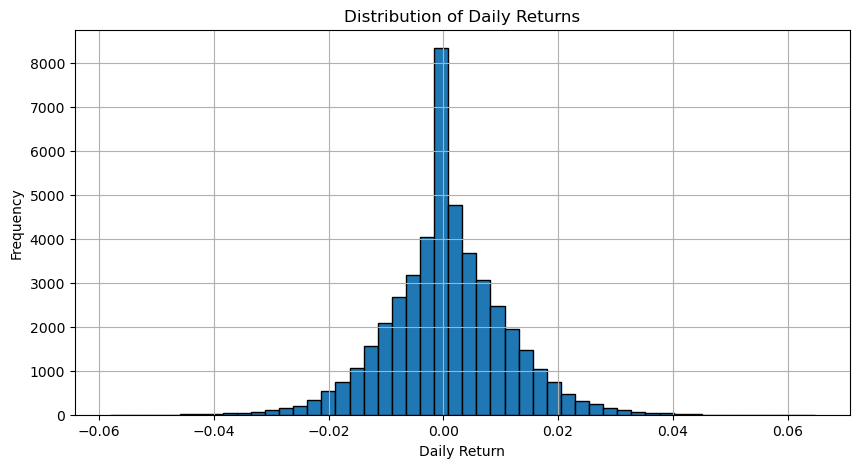

In [14]:
plt.figure(figsize=(10,5))

plt.hist(
    nav_history["daily_return"].dropna(),
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

In [16]:
print("Highest Returns")

display(
    nav_history.nlargest(
        10,
        "daily_return"
    )
)

print("Lowest Returns")

display(
    nav_history.nsmallest(
        10,
        "daily_return"
    )
)

Highest Returns


,amfi_code,date,nav,daily_return
24745,119598,2024-04-15,189.0742,0.064713
13226,118634,2024-03-19,110.5401,0.059304
5207,101207,2024-05-01,65.5882,0.054851
25566,119599,2023-01-10,153.2221,0.053320
25832,119599,2024-01-17,136.8239,0.051811
24155,119598,2022-01-10,96.0964,0.051113
24371,119598,2022-11-08,123.9704,0.049051
45082,149324,2022-11-23,98.3696,0.048490
24356,119598,2022-10-18,122.2757,0.048454
25091,119598,2025-08-12,200.8460,0.047123


Lowest Returns


,amfi_code,date,nav,daily_return
12774,118634,2022-06-24,67.2534,-0.058102
4917,101207,2023-03-22,56.8326,-0.051847
12952,118634,2023-03-01,113.5801,-0.050335
45312,149324,2023-10-11,111.8155,-0.048870
5560,101207,2025-09-08,62.3200,-0.048634
19804,119095,2022-12-23,73.9946,-0.048367
13333,118634,2024-08-15,114.5168,-0.048305
20307,119095,2024-11-27,78.1317,-0.046524
26048,119599,2024-11-14,112.8996,-0.045429
38520,125498,2024-03-11,131.4556,-0.045218


In [17]:
latest_dates = (
    nav_history.groupby("amfi_code")["date"]
    .max()
    .reset_index()
    .rename(columns={"date": "latest_date"})
)

display(latest_dates.head())

,amfi_code,latest_date
0,100016,2026-05-29
1,100025,2026-05-29
2,100033,2026-05-29
3,101206,2026-05-29
4,101207,2026-05-29


In [18]:
latest_nav = nav_history.merge(
    latest_dates,
    on="amfi_code"
)

latest_nav = latest_nav[
    latest_nav["date"] == latest_nav["latest_date"]
][["amfi_code", "nav"]]

latest_nav.rename(
    columns={"nav": "latest_nav"},
    inplace=True
)

display(latest_nav.head())

,amfi_code,latest_nav
1149,100016,583.6113
2299,100025,31.8843
3449,100033,342.0072
4599,101206,773.2939
5749,101207,53.9836


In [19]:
def calculate_cagr(years):
    
    records = []

    for fund in nav_history["amfi_code"].unique():

        df = nav_history[
            nav_history["amfi_code"] == fund
        ].sort_values("date")

        end_date = df["date"].max()

        start_date = end_date - pd.DateOffset(years=years)

        start_rows = df[df["date"] >= start_date]

        if start_rows.empty:
            continue

        start_nav = start_rows.iloc[0]["nav"]

        end_nav = df.iloc[-1]["nav"]

        cagr = ((end_nav / start_nav) ** (1 / years)) - 1

        records.append(
            {
                "amfi_code": fund,
                f"CAGR_{years}Y": cagr
            }
        )

    return pd.DataFrame(records)

In [20]:
cagr_1 = calculate_cagr(1)

display(cagr_1.head())

,amfi_code,CAGR_1Y
0,100016,-0.022243
1,100025,0.037050
2,100033,0.532324
3,101206,0.479241
4,101207,-0.239860


In [21]:
cagr_3 = calculate_cagr(3)

display(cagr_3.head())

,amfi_code,CAGR_3Y
0,100016,0.012926
1,100025,0.039164
2,100033,0.324425
3,101206,0.289677
4,101207,-0.041524


In [22]:
cagr_5 = calculate_cagr(5)

display(cagr_5.head())

,amfi_code,CAGR_5Y
0,100016,0.023168
1,100025,0.039127
2,100033,0.260741
3,101206,0.204427
4,101207,0.069533


In [23]:
cagr_table = (
    cagr_1
    .merge(cagr_3, on="amfi_code", how="outer")
    .merge(cagr_5, on="amfi_code", how="outer")
)

In [24]:
cagr_table = cagr_table.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

In [25]:
cagr_table = cagr_table[
    [
        "amfi_code",
        "scheme_name",
        "CAGR_1Y",
        "CAGR_3Y",
        "CAGR_5Y"
    ]
]

display(cagr_table.head())

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.022243,0.012926,0.023168
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.037050,0.039164,0.039127
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.532324,0.324425,0.260741
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.479241,0.289677,0.204427
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.239860,-0.041524,0.069533


In [26]:
cagr_table["CAGR_1Y"] = cagr_table["CAGR_1Y"] * 100
cagr_table["CAGR_3Y"] = cagr_table["CAGR_3Y"] * 100
cagr_table["CAGR_5Y"] = cagr_table["CAGR_5Y"] * 100

In [27]:
cagr_table[
    [
        "CAGR_1Y",
        "CAGR_3Y",
        "CAGR_5Y"
    ]
] = cagr_table[
    [
        "CAGR_1Y",
        "CAGR_3Y",
        "CAGR_5Y"
    ]
].round(2)

In [28]:
display(cagr_table)

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-2.22,1.29,2.32
1,100025,HDFC Short Term Debt Fund - Regular - Growth,3.70,3.92,3.91
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.23,32.44,26.07
3,101206,ABSL Frontline Equity Fund - Regular - Growth,47.92,28.97,20.44
4,101207,ABSL Small Cap Fund - Regular - Growth,-23.99,-4.15,6.95
5,101208,ABSL Liquid Fund - Regular - Growth,7.24,6.32,5.71
6,102885,UTI Nifty 50 Index Fund - Regular - Growth,20.21,19.67,15.88
7,102886,UTI Mid Cap Fund - Regular - Growth,-16.80,-0.77,1.03
8,102887,UTI Flexi Cap Fund - Regular - Growth,13.58,25.56,14.68
9,118632,Nippon India Large Cap Fund - Regular - Growth,33.98,22.65,20.88


In [29]:
display(
    cagr_table.sort_values(
        "CAGR_3Y",
        ascending=False
    ).head(10)
)

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
16,119094,Axis Midcap Fund - Regular - Growth,22.26,35.11,24.45
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,20.36,34.00,26.80
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,13.06,32.49,20.23
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.23,32.44,26.07
25,120505,ICICI Pru Midcap Fund - Regular - Growth,29.60,31.78,28.38
19,119551,SBI Bluechip Fund - Regular Plan - Growth,60.44,30.46,22.38
30,120843,Kotak Flexicap Fund - Regular - Growth,26.66,29.58,26.74
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,39.75,29.18,27.63
3,101206,ABSL Frontline Equity Fund - Regular - Growth,47.92,28.97,20.44
39,149324,DSP Small Cap Fund - Regular - Growth,65.14,27.00,27.92


In [30]:
RISK_FREE_RATE = 0.065
TRADING_DAYS = 252

In [31]:
performance_metrics = (
    nav_history
    .groupby("amfi_code")["daily_return"]
    .agg(
        mean_daily_return="mean",
        daily_volatility="std"
    )
    .reset_index()
)

performance_metrics["annual_return"] = (
    performance_metrics["mean_daily_return"] * TRADING_DAYS
)

performance_metrics["annual_volatility"] = (
    performance_metrics["daily_volatility"] * np.sqrt(TRADING_DAYS)
)

display(performance_metrics.head())

,amfi_code,mean_daily_return,daily_volatility,annual_return,annual_volatility
0,100016,0.000142,0.009164,0.035683,0.145481
1,100025,0.000170,0.002460,0.042854,0.039052
2,100033,0.001080,0.011929,0.272111,0.189367
3,101206,0.000852,0.009177,0.214647,0.145682
4,101207,0.000424,0.016251,0.106962,0.257973


In [34]:
performance_metrics["Sharpe_Ratio"] = (
    (performance_metrics["annual_return"] - RISK_FREE_RATE)
    / performance_metrics["annual_volatility"]
)

In [35]:
performance_metrics["Sharpe_Rank"] = (
    performance_metrics["Sharpe_Ratio"]
    .rank(ascending=False, method="dense")
)

display(
    performance_metrics.sort_values(
        "Sharpe_Ratio",
        ascending=False
    ).head(10)
)

,amfi_code,mean_daily_return,daily_volatility,annual_return,annual_volatility,Sharpe_Ratio,Sharpe_Rank
34,148567,0.001074,0.008941,0.270566,0.141937,1.448291,1.0
30,120843,0.001082,0.010008,0.272602,0.158870,1.306744,2.0
36,148569,0.001124,0.011134,0.283262,0.176740,1.234930,3.0
19,119551,0.000917,0.008656,0.231033,0.137414,1.208267,4.0
25,120505,0.001161,0.012152,0.292653,0.192909,1.180101,5.0
38,149323,0.001055,0.011179,0.265908,0.177462,1.132122,6.0
2,100033,0.001080,0.011929,0.272111,0.189367,1.093699,7.0
9,118632,0.000865,0.008913,0.218037,0.141484,1.081659,8.0
3,101206,0.000852,0.009177,0.214647,0.145682,1.027213,9.0
24,120504,0.000843,0.009048,0.212448,0.143638,1.026524,10.0


In [36]:
negative_returns = nav_history.copy()

negative_returns["negative_return"] = negative_returns["daily_return"].where(
    negative_returns["daily_return"] < 0
)

downside = (
    negative_returns
    .groupby("amfi_code")["negative_return"]
    .std()
    .reset_index()
)

downside.rename(
    columns={"negative_return": "downside_std"},
    inplace=True
)

display(downside.head())

,amfi_code,downside_std
0,100016,0.005261
1,100025,0.001481
2,100033,0.007133
3,101206,0.005238
4,101207,0.009555


In [37]:
performance_metrics = performance_metrics.merge(
    downside,
    on="amfi_code",
    how="left"
)

In [38]:
performance_metrics["annual_downside_std"] = (
    performance_metrics["downside_std"] * np.sqrt(TRADING_DAYS)
)

In [39]:
performance_metrics["Sortino_Ratio"] = (
    (performance_metrics["annual_return"] - RISK_FREE_RATE)
    / performance_metrics["annual_downside_std"]
)

In [40]:
performance_metrics["Sortino_Rank"] = (
    performance_metrics["Sortino_Ratio"]
    .rank(ascending=False, method="dense")
)

display(
    performance_metrics.sort_values(
        "Sortino_Ratio",
        ascending=False
    ).head(10)
)

,amfi_code,mean_daily_return,daily_volatility,annual_return,annual_volatility,Sharpe_Ratio,Sharpe_Rank,downside_std,annual_downside_std,Sortino_Ratio,Sortino_Rank
34,148567,0.001074,0.008941,0.270566,0.141937,1.448291,1.0,0.005428,0.086168,2.385644,1.0
30,120843,0.001082,0.010008,0.272602,0.158870,1.306744,2.0,0.005531,0.087806,2.364320,2.0
36,148569,0.001124,0.011134,0.283262,0.176740,1.234930,3.0,0.006404,0.101663,2.146914,3.0
19,119551,0.000917,0.008656,0.231033,0.137414,1.208267,4.0,0.004887,0.077576,2.140267,4.0
25,120505,0.001161,0.012152,0.292653,0.192909,1.180101,5.0,0.007067,0.112180,2.029353,5.0
38,149323,0.001055,0.011179,0.265908,0.177462,1.132122,6.0,0.006750,0.107145,1.875101,6.0
9,118632,0.000865,0.008913,0.218037,0.141484,1.081659,8.0,0.005211,0.082717,1.850133,7.0
2,100033,0.001080,0.011929,0.272111,0.189367,1.093699,7.0,0.007133,0.113229,1.829134,8.0
24,120504,0.000843,0.009048,0.212448,0.143638,1.026524,10.0,0.005145,0.081675,1.805294,9.0
3,101206,0.000852,0.009177,0.214647,0.145682,1.027213,9.0,0.005238,0.083157,1.799563,10.0


In [41]:
performance_metrics = performance_metrics.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

In [42]:
performance_metrics = performance_metrics[
    [
        "amfi_code",
        "scheme_name",
        "annual_return",
        "annual_volatility",
        "Sharpe_Ratio",
        "Sharpe_Rank",
        "Sortino_Ratio",
        "Sortino_Rank"
    ]
]

display(performance_metrics.head())

,amfi_code,scheme_name,annual_return,annual_volatility,Sharpe_Ratio,Sharpe_Rank,Sortino_Ratio,Sortino_Rank
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.035683,0.145481,-0.201517,35.0,-0.351047,36.0
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.042854,0.039052,-0.567095,39.0,-0.941821,39.0
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.272111,0.189367,1.093699,7.0,1.829134,8.0
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.214647,0.145682,1.027213,9.0,1.799563,10.0
4,101207,ABSL Small Cap Fund - Regular - Growth,0.106962,0.257973,0.162661,28.0,0.276644,28.0


In [43]:
display(
    performance_metrics.sort_values(
        "Sharpe_Ratio",
        ascending=False
    ).head(10)
)

,amfi_code,scheme_name,annual_return,annual_volatility,Sharpe_Ratio,Sharpe_Rank,Sortino_Ratio,Sortino_Rank
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.270566,0.141937,1.448291,1.0,2.385644,1.0
30,120843,Kotak Flexicap Fund - Regular - Growth,0.272602,0.158870,1.306744,2.0,2.364320,2.0
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.283262,0.176740,1.234930,3.0,2.146914,3.0
19,119551,SBI Bluechip Fund - Regular Plan - Growth,0.231033,0.137414,1.208267,4.0,2.140267,4.0
25,120505,ICICI Pru Midcap Fund - Regular - Growth,0.292653,0.192909,1.180101,5.0,2.029353,5.0
38,149323,DSP Midcap Fund - Regular - Growth,0.265908,0.177462,1.132122,6.0,1.875101,6.0
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.272111,0.189367,1.093699,7.0,1.829134,8.0
9,118632,Nippon India Large Cap Fund - Regular - Growth,0.218037,0.141484,1.081659,8.0,1.850133,7.0
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.214647,0.145682,1.027213,9.0,1.799563,10.0
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.212448,0.143638,1.026524,10.0,1.805294,9.0


In [44]:
display(
    performance_metrics.sort_values(
        "Sortino_Ratio",
        ascending=False
    ).head(10)
)

,amfi_code,scheme_name,annual_return,annual_volatility,Sharpe_Ratio,Sharpe_Rank,Sortino_Ratio,Sortino_Rank
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.270566,0.141937,1.448291,1.0,2.385644,1.0
30,120843,Kotak Flexicap Fund - Regular - Growth,0.272602,0.158870,1.306744,2.0,2.364320,2.0
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.283262,0.176740,1.234930,3.0,2.146914,3.0
19,119551,SBI Bluechip Fund - Regular Plan - Growth,0.231033,0.137414,1.208267,4.0,2.140267,4.0
25,120505,ICICI Pru Midcap Fund - Regular - Growth,0.292653,0.192909,1.180101,5.0,2.029353,5.0
38,149323,DSP Midcap Fund - Regular - Growth,0.265908,0.177462,1.132122,6.0,1.875101,6.0
9,118632,Nippon India Large Cap Fund - Regular - Growth,0.218037,0.141484,1.081659,8.0,1.850133,7.0
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.272111,0.189367,1.093699,7.0,1.829134,8.0
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.212448,0.143638,1.026524,10.0,1.805294,9.0
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.214647,0.145682,1.027213,9.0,1.799563,10.0


In [48]:
benchmark = pd.read_csv("../data/processed/10_benchmark_indices_clean.csv")

display(benchmark.head())

print(benchmark.columns.tolist())

benchmark.info()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


['date', 'index_name', 'close_value']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         8050 non-null   object 
 1   index_name   8050 non-null   object 
 2   close_value  8050 non-null   float64
dtypes: float64(1), object(2)
memory usage: 188.8+ KB


In [49]:
benchmark = pd.read_csv("../data/processed/10_benchmark_indices_clean.csv")

benchmark["date"] = pd.to_datetime(benchmark["date"])

In [50]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

display(nifty100.head())

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [51]:
nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

display(nifty100.head())

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [52]:
nifty100 = nifty100[
    [
        "date",
        "benchmark_return"
    ]
]

In [53]:
fund_returns = nav_history[
    [
        "amfi_code",
        "date",
        "daily_return"
    ]
].dropna()

In [54]:
merged_returns = fund_returns.merge(
    nifty100,
    on="date",
    how="inner"
)

display(merged_returns.head())


,amfi_code,date,daily_return,benchmark_return
0,100016,2022-01-04,-0.010306,-0.013540
1,100016,2022-01-05,0.012865,0.004003
2,100016,2022-01-06,-0.011377,-0.002935
3,100016,2022-01-07,-0.001210,0.006150
4,100016,2022-01-10,-0.008639,-0.008351


In [55]:
alpha_beta = []

for fund in merged_returns["amfi_code"].unique():

    df = merged_returns[
        merged_returns["amfi_code"] == fund
    ]

    slope, intercept, r_value, p_value, std_err = linregress(
        df["benchmark_return"],
        df["daily_return"]
    )

    alpha_beta.append(
        {
            "amfi_code": fund,
            "Alpha": intercept * 252,
            "Beta": slope
        }
    )

alpha_beta = pd.DataFrame(alpha_beta)

display(alpha_beta.head())

,amfi_code,Alpha,Beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [56]:
alpha_beta = alpha_beta.merge(
    fund_master[
        [
            "amfi_code",
            "scheme_name"
        ]
    ],
    on="amfi_code",
    how="left"
)

In [57]:
alpha_beta = alpha_beta[
    [
        "amfi_code",
        "scheme_name",
        "Alpha",
        "Beta"
    ]
]

display(alpha_beta.head())

,amfi_code,scheme_name,Alpha,Beta
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.037476,-0.058268
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.042818,0.001158
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.271954,0.005104
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.213998,0.021086
4,101207,ABSL Small Cap Fund - Regular - Growth,0.108971,-0.065289


In [58]:
alpha_beta["Alpha_Rank"] = (
    alpha_beta["Alpha"]
    .rank(
        ascending=False,
        method="dense"
    )
)

display(
    alpha_beta.sort_values(
        "Alpha",
        ascending=False
    ).head(10)
)

,amfi_code,scheme_name,Alpha,Beta,Alpha_Rank
21,119598,SBI Small Cap Fund - Regular Plan - Growth,0.303370,-0.023196,1.0
39,149324,DSP Small Cap Fund - Regular - Growth,0.300579,0.011455,2.0
25,120505,ICICI Pru Midcap Fund - Regular - Growth,0.292636,0.000549,3.0
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.282704,0.018134,4.0
30,120843,Kotak Flexicap Fund - Regular - Growth,0.273305,-0.022830,5.0
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.271954,0.005104,6.0
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.269838,0.023684,7.0
38,149323,DSP Midcap Fund - Regular - Growth,0.265986,-0.002523,8.0
16,119094,Axis Midcap Fund - Regular - Growth,0.260767,-0.066265,9.0
19,119551,SBI Bluechip Fund - Regular Plan - Growth,0.232010,-0.031751,10.0


In [65]:
alpha_beta.to_csv(
    "../outputs/alpha_beta.csv",
    index=False
)

In [66]:
nav_history["running_max"] = (
    nav_history
    .groupby("amfi_code")["nav"]
    .cummax()
)

In [67]:
nav_history["drawdown"] = (
    nav_history["nav"]
    / nav_history["running_max"]
) - 1

In [68]:
max_drawdown = (
    nav_history
    .groupby("amfi_code")["drawdown"]
    .min()
    .reset_index()
)

max_drawdown.rename(
    columns={
        "drawdown":"Max_Drawdown"
    },
    inplace=True
)

display(max_drawdown.head())

,amfi_code,Max_Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [69]:
worst_dates = (
    nav_history
    .loc[
        nav_history.groupby("amfi_code")["drawdown"].idxmin()
    ][
        [
            "amfi_code",
            "date",
            "drawdown"
        ]
    ]
)

worst_dates.rename(
    columns={
        "date":"Worst_Drawdown_Date"
    },
    inplace=True
)

display(worst_dates.head())

,amfi_code,Worst_Drawdown_Date,drawdown
183,100016,2022-09-15,-0.247344
1559,100025,2023-07-28,-0.043083
2393,100033,2022-05-12,-0.162172
3842,101206,2023-07-05,-0.112916
5735,101207,2026-05-11,-0.354469


In [70]:
drawdown_table = max_drawdown.merge(
    worst_dates[
        [
            "amfi_code",
            "Worst_Drawdown_Date"
        ]
    ],
    on="amfi_code"
)

In [71]:
drawdown_table = drawdown_table.merge(
    fund_master[
        [
            "amfi_code",
            "scheme_name"
        ]
    ],
    on="amfi_code",
    how="left"
)

In [72]:
drawdown_table = drawdown_table[
    [
        "amfi_code",
        "scheme_name",
        "Max_Drawdown",
        "Worst_Drawdown_Date"
    ]
]

display(drawdown_table.head())

,amfi_code,scheme_name,Max_Drawdown,Worst_Drawdown_Date
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.247344,2022-09-15
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.043083,2023-07-28
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.162172,2022-05-12
3,101206,ABSL Frontline Equity Fund - Regular - Growth,-0.112916,2023-07-05
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.354469,2026-05-11


In [73]:
drawdown_table["Drawdown_Rank"] = (
    drawdown_table["Max_Drawdown"]
    .rank(
        ascending=False,
        method="dense"
    )
)

In [74]:
display(
    drawdown_table.sort_values(
        "Drawdown_Rank"
    ).head(10)
)

,amfi_code,scheme_name,Max_Drawdown,Worst_Drawdown_Date,Drawdown_Rank
27,120507,ICICI Pru Liquid Fund - Regular - Growth,-0.000977,2025-10-20,1.0
31,120844,Kotak Liquid Fund - Regular - Growth,-0.001163,2024-04-30,2.0
5,101208,ABSL Liquid Fund - Regular - Growth,-0.001622,2023-09-12,3.0
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.043083,2023-07-28,4.0
18,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,-0.043287,2025-04-01,5.0
13,118636,Nippon India Gilt Securities Fund - Regular - ...,-0.083164,2024-02-09,6.0
6,102885,UTI Nifty 50 Index Fund - Regular - Growth,-0.108599,2022-03-29,7.0
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,-0.112657,2023-10-20,8.0
3,101206,ABSL Frontline Equity Fund - Regular - Growth,-0.112916,2023-07-05,9.0
12,118635,Nippon India ETF Nifty 50 BeES,-0.116506,2022-06-09,10.0


In [75]:
drawdown_table.to_csv(
    "../outputs/drawdown_table.csv",
    index=False
)

In [76]:
expense = fund_master[
    [
        "amfi_code",
        "expense_ratio_pct"
    ]
].copy()

display(expense.head())

,amfi_code,expense_ratio_pct
0,119551,1.54
1,119552,0.66
2,119598,1.43
3,119599,0.72
4,119120,0.77


In [77]:
expense["Expense_Rank"] = (
    expense["expense_ratio_pct"]
    .rank(
        ascending=True,
        method="dense"
    )
)

display(expense.head())

,amfi_code,expense_ratio_pct,Expense_Rank
0,119551,1.54,24.0
1,119552,0.66,4.0
2,119598,1.43,18.0
3,119599,0.72,5.0
4,119120,0.77,8.0


In [78]:
scorecard = cagr_table[
    [
        "amfi_code",
        "CAGR_3Y"
    ]
].copy()

In [79]:
scorecard["CAGR_Rank"] = (
    scorecard["CAGR_3Y"]
    .rank(
        ascending=False,
        method="dense"
    )
)

In [80]:
scorecard = scorecard.merge(
    performance_metrics[
        [
            "amfi_code",
            "Sharpe_Rank"
        ]
    ],
    on="amfi_code"
)

In [81]:
scorecard = scorecard.merge(
    alpha_beta[
        [
            "amfi_code",
            "Alpha_Rank"
        ]
    ],
    on="amfi_code"
)

In [82]:
scorecard = scorecard.merge(
    expense[
        [
            "amfi_code",
            "Expense_Rank"
        ]
    ],
    on="amfi_code"
)

In [83]:
scorecard = scorecard.merge(
    drawdown_table[
        [
            "amfi_code",
            "Drawdown_Rank"
        ]
    ],
    on="amfi_code"
)

In [84]:
scorecard = scorecard.merge(
    fund_master[
        [
            "amfi_code",
            "scheme_name"
        ]
    ],
    on="amfi_code"
)

In [85]:
scorecard["Raw_Score"] = (

    0.30 * scorecard["CAGR_Rank"]

    +

    0.25 * scorecard["Sharpe_Rank"]

    +

    0.20 * scorecard["Alpha_Rank"]

    +

    0.15 * scorecard["Expense_Rank"]

    +

    0.10 * scorecard["Drawdown_Rank"]

)

In [86]:
max_score = scorecard["Raw_Score"].max()

min_score = scorecard["Raw_Score"].min()

scorecard["Fund_Score"] = (

    (max_score - scorecard["Raw_Score"])

    /

    (max_score - min_score)

) * 100

In [87]:
scorecard["Fund_Score"] = scorecard["Fund_Score"].round(2)

In [88]:
scorecard = scorecard.sort_values(

    "Fund_Score",

    ascending=False

).reset_index(drop=True)

scorecard["Overall_Rank"] = scorecard.index + 1

In [89]:
scorecard = scorecard[
    [

        "Overall_Rank",

        "amfi_code",

        "scheme_name",

        "Fund_Score",

        "CAGR_Rank",

        "Sharpe_Rank",

        "Alpha_Rank",

        "Expense_Rank",

        "Drawdown_Rank"

    ]
]

display(scorecard.head(10))

,Overall_Rank,amfi_code,scheme_name,Fund_Score,CAGR_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank
0,1,148567,Mirae Asset Large Cap Fund - Regular - Growth,100.00,2.0,1.0,7.0,20.0,8.0
1,2,120843,Kotak Flexicap Fund - Regular - Growth,94.08,7.0,2.0,5.0,19.0,13.0
2,3,120505,ICICI Pru Midcap Fund - Regular - Growth,93.38,5.0,5.0,3.0,14.0,25.0
3,4,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,91.81,4.0,7.0,6.0,15.0,20.0
4,5,120504,ICICI Pru Bluechip Fund - Direct - Growth,90.24,3.0,10.0,13.0,11.0,12.0
5,6,119094,Axis Midcap Fund - Regular - Growth,86.59,1.0,11.0,9.0,15.0,28.0
6,7,119551,SBI Bluechip Fund - Regular Plan - Growth,85.89,6.0,4.0,10.0,24.0,17.0
7,8,148569,Mirae Asset Tax Saver Fund - Regular - Growth,84.84,8.0,3.0,4.0,29.0,21.0
8,9,101206,ABSL Frontline Equity Fund - Regular - Growth,77.18,9.0,9.0,12.0,29.0,9.0
9,10,149323,DSP Midcap Fund - Regular - Growth,75.44,11.0,6.0,8.0,30.0,22.0


In [90]:
scorecard.to_csv(

    "../outputs/fund_scorecard.csv",

    index=False

)

In [91]:
display(scorecard.head(10))

,Overall_Rank,amfi_code,scheme_name,Fund_Score,CAGR_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank
0,1,148567,Mirae Asset Large Cap Fund - Regular - Growth,100.00,2.0,1.0,7.0,20.0,8.0
1,2,120843,Kotak Flexicap Fund - Regular - Growth,94.08,7.0,2.0,5.0,19.0,13.0
2,3,120505,ICICI Pru Midcap Fund - Regular - Growth,93.38,5.0,5.0,3.0,14.0,25.0
3,4,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,91.81,4.0,7.0,6.0,15.0,20.0
4,5,120504,ICICI Pru Bluechip Fund - Direct - Growth,90.24,3.0,10.0,13.0,11.0,12.0
5,6,119094,Axis Midcap Fund - Regular - Growth,86.59,1.0,11.0,9.0,15.0,28.0
6,7,119551,SBI Bluechip Fund - Regular Plan - Growth,85.89,6.0,4.0,10.0,24.0,17.0
7,8,148569,Mirae Asset Tax Saver Fund - Regular - Growth,84.84,8.0,3.0,4.0,29.0,21.0
8,9,101206,ABSL Frontline Equity Fund - Regular - Growth,77.18,9.0,9.0,12.0,29.0,9.0
9,10,149323,DSP Midcap Fund - Regular - Growth,75.44,11.0,6.0,8.0,30.0,22.0


In [92]:
top5_funds = scorecard.head(5)

top5_codes = top5_funds["amfi_code"].tolist()

display(top5_funds)

,Overall_Rank,amfi_code,scheme_name,Fund_Score,CAGR_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank
0,1,148567,Mirae Asset Large Cap Fund - Regular - Growth,100.00,2.0,1.0,7.0,20.0,8.0
1,2,120843,Kotak Flexicap Fund - Regular - Growth,94.08,7.0,2.0,5.0,19.0,13.0
2,3,120505,ICICI Pru Midcap Fund - Regular - Growth,93.38,5.0,5.0,3.0,14.0,25.0
3,4,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,91.81,4.0,7.0,6.0,15.0,20.0
4,5,120504,ICICI Pru Bluechip Fund - Direct - Growth,90.24,3.0,10.0,13.0,11.0,12.0


In [93]:
nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty50["date"] = pd.to_datetime(nifty50["date"])

nifty50 = nifty50.sort_values("date")

nifty50["normalized"] = (
    nifty50["close_value"]
    / nifty50["close_value"].iloc[0]
) * 100

In [94]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100["date"] = pd.to_datetime(nifty100["date"])

nifty100 = nifty100.sort_values("date")

nifty100["normalized"] = (
    nifty100["close_value"]
    / nifty100["close_value"].iloc[0]
) * 100

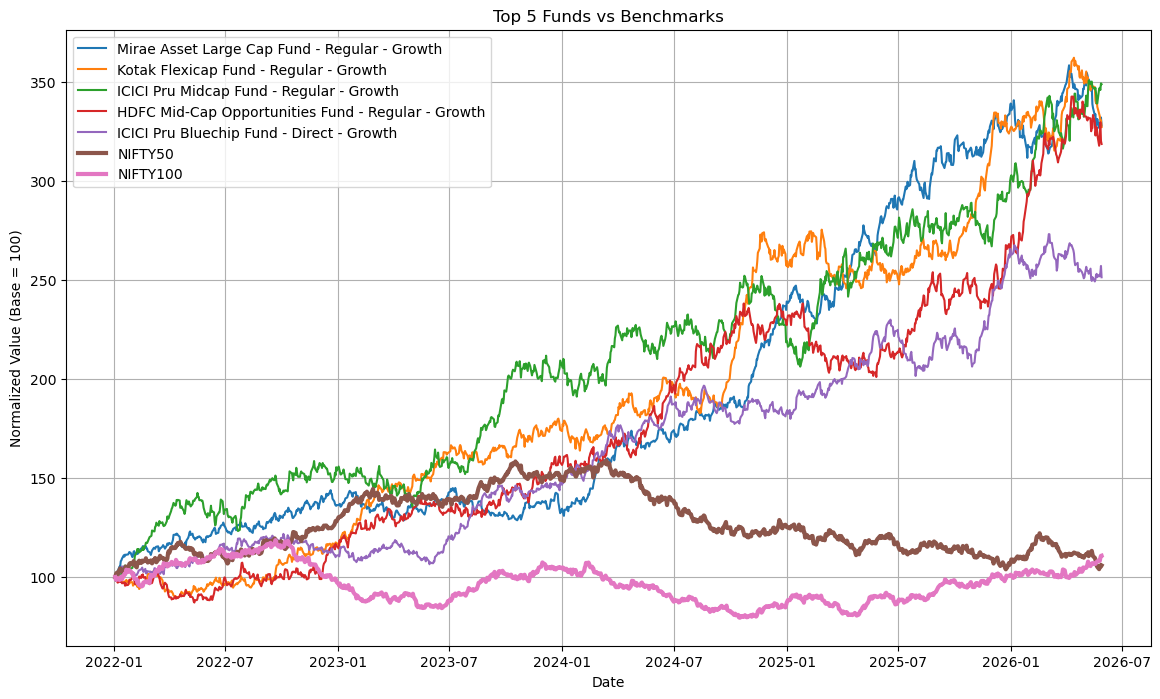

In [95]:
plt.figure(figsize=(14,8))

for code in top5_codes:

    fund = nav_history[
        nav_history["amfi_code"] == code
    ].copy()

    fund = fund.sort_values("date")

    fund["normalized"] = (
        fund["nav"]
        / fund["nav"].iloc[0]
    ) * 100

    name = fund_master.loc[
        fund_master["amfi_code"] == code,
        "scheme_name"
    ].values[0]

    plt.plot(
        fund["date"],
        fund["normalized"],
        label=name
    )

plt.plot(
    nifty50["date"],
    nifty50["normalized"],
    linewidth=3,
    label="NIFTY50"
)

plt.plot(
    nifty100["date"],
    nifty100["normalized"],
    linewidth=3,
    label="NIFTY100"
)

plt.title("Top 5 Funds vs Benchmarks")

plt.xlabel("Date")

plt.ylabel("Normalized Value (Base = 100)")

plt.legend()

plt.grid(True)

plt.show()

In [96]:
nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

In [97]:
tracking_error = []

for code in top5_codes:

    fund = nav_history[
        nav_history["amfi_code"] == code
    ][
        [
            "date",
            "daily_return"
        ]
    ].dropna()

    merged = fund.merge(
        nifty100[
            [
                "date",
                "benchmark_return"
            ]
        ],
        on="date",
        how="inner"
    )

    te = (
        (merged["daily_return"] - merged["benchmark_return"])
        .std()
        * np.sqrt(252)
    )

    tracking_error.append(
        {
            "amfi_code": code,
            "Tracking_Error": te
        }
    )

tracking_error = pd.DataFrame(tracking_error)

display(tracking_error)

,amfi_code,Tracking_Error
0,148567,0.189664
1,120843,0.206425
2,120505,0.231968
3,100033,0.228699
4,120504,0.191587


In [98]:
tracking_error = tracking_error.merge(

    fund_master[
        [
            "amfi_code",
            "scheme_name"
        ]
    ],

    on="amfi_code"

)

display(tracking_error)

,amfi_code,Tracking_Error,scheme_name
0,148567,0.189664,Mirae Asset Large Cap Fund - Regular - Growth
1,120843,0.206425,Kotak Flexicap Fund - Regular - Growth
2,120505,0.231968,ICICI Pru Midcap Fund - Regular - Growth
3,100033,0.228699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
4,120504,0.191587,ICICI Pru Bluechip Fund - Direct - Growth


In [99]:
tracking_error.to_csv(

    "../outputs/tracking_error.csv",

    index=False

)

In [100]:
import os

os.makedirs("../plots", exist_ok=True)

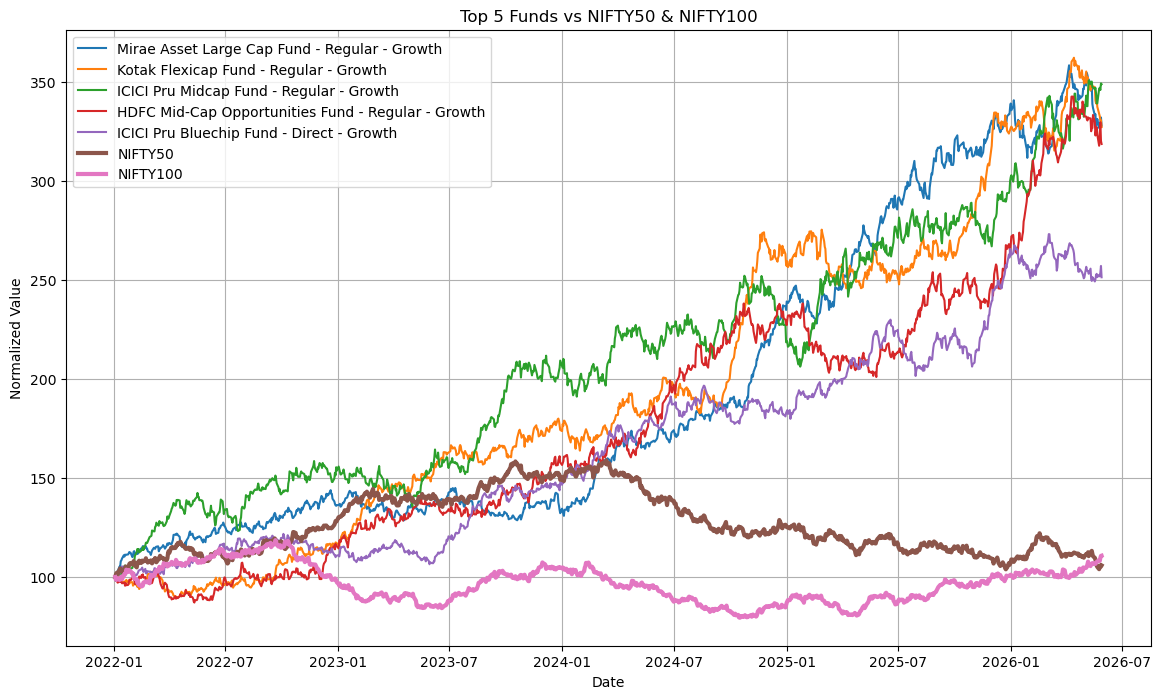

In [101]:
plt.figure(figsize=(14,8))

for code in top5_codes:

    fund = nav_history[
        nav_history["amfi_code"] == code
    ].copy()

    fund = fund.sort_values("date")

    fund["normalized"] = (
        fund["nav"]
        / fund["nav"].iloc[0]
    ) * 100

    name = fund_master.loc[
        fund_master["amfi_code"] == code,
        "scheme_name"
    ].values[0]

    plt.plot(
        fund["date"],
        fund["normalized"],
        label=name
    )

plt.plot(
    nifty50["date"],
    nifty50["normalized"],
    linewidth=3,
    label="NIFTY50"
)

plt.plot(
    nifty100["date"],
    nifty100["normalized"],
    linewidth=3,
    label="NIFTY100"
)

plt.title("Top 5 Funds vs NIFTY50 & NIFTY100")

plt.xlabel("Date")

plt.ylabel("Normalized Value")

plt.legend()

plt.grid(True)

plt.savefig(
    "../plots/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()